# Sentiment Analysis: Preprocessing Gmail and WhatsApp Data
## Preparing Unseen Communication Data for Model Evaluation

**Author:** David

### Overview
This notebook handles the cleaning and standardization of our evaluation dataset. Unlike the general training data, these samples are exported directly from real-world student communication channels. They contain noise such as HTML tags, email signatures, and platform-specific artifacts that must be cleaned to ensure a reliable evaluation of our models.

## 1. Environment Setup & Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")

gmail_path = '../data/raw/gmail_raw.csv'
whatsapp_path = '../data/raw/whatsapp_raw.csv'

df_gmail = pd.read_csv(gmail_path)
df_whatsapp = pd.read_csv(whatsapp_path)

print(f"Raw Gmail records: {len(df_gmail)}")
print(f"Raw WhatsApp records: {len(df_whatsapp)}")

df_gmail = df_gmail.drop_duplicates(subset=['text']).reset_index(drop=True)
df_whatsapp = df_whatsapp.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"Gmail records after deduplication: {len(df_gmail)}")
print(f"WhatsApp records after deduplication: {len(df_whatsapp)}")

Raw Gmail records: 364
Raw WhatsApp records: 364
Gmail records after deduplication: 348
WhatsApp records after deduplication: 318


## 2. Advanced Cleaning Logic
We define a robust cleaning function using regular expressions to strip signatures, HTML, and specific noise markers identified during EDA.

In [14]:
def clean_comm_text(text):
    # Remove HTML tags (<div>, <br>, etc.)
    text = re.sub(r'<.*?>', '', text)
    
    # Remove Forwarded message markers and signatures
    text = re.sub(r'--- Forwarded message ---', '', text)
    text = re.sub(r'Please consider the environment', '', text, flags=re.I)
    text = re.sub(r'Sent from my (iPhone|mobile|Android|iPhone)', '', text, flags=re.I)
    text = re.sub(r'Best regards, .*', '', text, flags=re.I)
    
    # Remove service markers (MTN:, GitHub:, etc.)
    text = re.sub(r'(MTN|GitHub|Vercel|Udemy|Vultr|CodeMagic|LinkedIn|Amazon|Railway|Netlify|Heroku):', '', text, flags=re.I)

    # Remove specific noise characters (!!!, ???, @user)
    text = re.sub(r'!!!|\?\?\?|@user', '', text)
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to both streams
df_gmail['clean_text'] = df_gmail['text'].apply(clean_comm_text)
df_whatsapp['clean_text'] = df_whatsapp['text'].apply(clean_comm_text)

df_gmail[['text', 'clean_text']].head()

,text,clean_text
0,@user GitHub: Security alert - A new SSH key w...,Security alert - A new SSH key was added.
1,!!! Vultr: Monthly invoice is ready for review...,Monthly invoice is ready for review.
2,<br> Coursera: Financial Aid for 'Machine Lear...,Coursera: Financial Aid for 'Machine Learning'...
3,@user Udemy: Registration Successful! Welcome ...,Registration Successful! Welcome to 'Deep Lear...
4,??? You've won a $1000 prize! Claim your rewar...,You've won a $1000 prize! Claim your reward now!


## 3. Feature Selection & Merging
We drop the 'noise' columns (meta_data, priority, is_starred, etc.) and merge the two streams into a unified testing dataset.

In [15]:
# Tag sources before merging for visualization
df_gmail['source'] = 'Gmail'
df_whatsapp['source'] = 'WhatsApp'

# Select final columns
gmail_final = df_gmail[['clean_text', 'sentiment', 'source']].rename(columns={'clean_text': 'text'})
whatsapp_final = df_whatsapp[['clean_text', 'sentiment', 'source']].rename(columns={'clean_text': 'text'})

# Merge
test_dataset = pd.concat([gmail_final, whatsapp_final], ignore_index=True)
test_dataset = test_dataset.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Final Test Dataset Size after deduplication: {len(test_dataset)}")

Final Test Dataset Size after deduplication: 177


## 4. Visualizing the Test Data Distribution

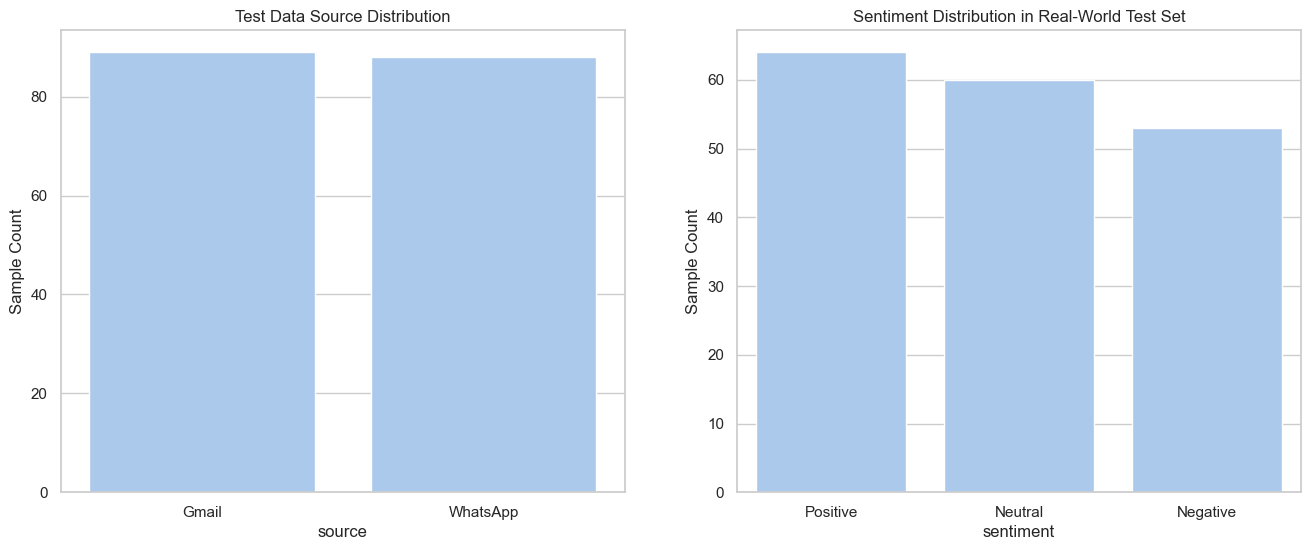

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Source Contribution
sns.countplot(data=test_dataset, x='source', ax=ax[0])
ax[0].set_title('Test Data Source Distribution')
ax[0].set_ylabel('Sample Count')

# 2. Sentiment Distribution (Verification of Balance)
sns.countplot(data=test_dataset, x='sentiment', ax=ax[1], order=['Positive', 'Neutral', 'Negative'])
ax[1].set_title('Sentiment Distribution in Real-World Test Set')
ax[1].set_ylabel('Sample Count')

plt.show()

## 5. Text Length Analysis
Comparing the linguistic complexity of Gmail vs. WhatsApp samples.

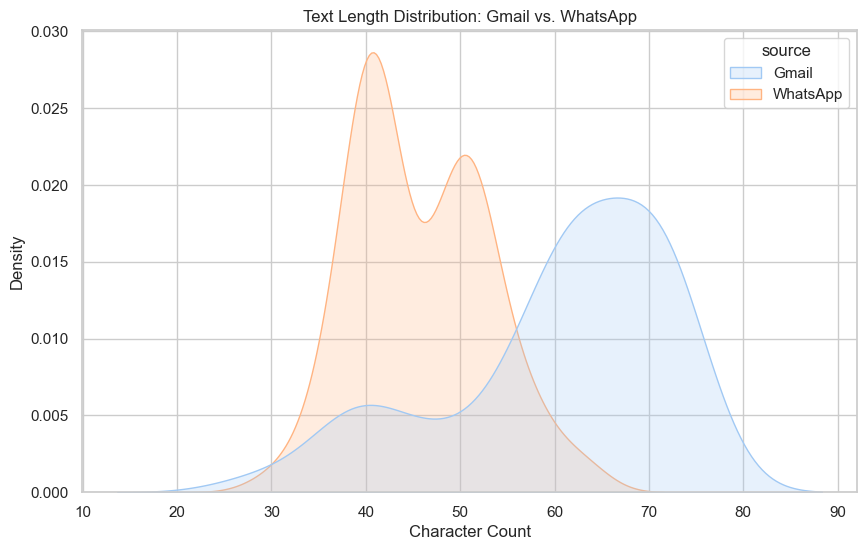

In [17]:
test_dataset['char_count'] = test_dataset['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=test_dataset, x='char_count', hue='source', fill=True)
plt.title('Text Length Distribution: Gmail vs. WhatsApp')
plt.xlabel('Character Count')
plt.show()

## 7. Exporting to Processed Folder
We save the final, cleaned benchmark for model evaluation.

In [18]:
output_path = '../data/processed/student_test_dataset.csv'
test_dataset[['text', 'sentiment']].to_csv(output_path, index=False)
print(f"Success! Cleaned test set saved to: {output_path}")

Success! Cleaned test set saved to: ../data/processed/student_test_dataset.csv
